<a href="https://colab.research.google.com/github/kkangmen/Diabetes-Classification-Project/blob/dev/3way-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Scikit-learn 및 Imbalanced-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

In [ ]:
file_path = '/content/drive/MyDrive/teamproject/Diabetes-Classification-Project/diabetes_dataset.csv'
data = pd.read_csv(file_path)

print(data.shape) # (행, 열) = (100000, 31)
print(data.head(10))

(100000, 31)
   age  gender ethnicity education_level  income_level employment_status  \
0   58    Male     Asian      Highschool  Lower-Middle          Employed   
1   48  Female     White      Highschool        Middle          Employed   
2   60    Male  Hispanic      Highschool        Middle        Unemployed   
3   74  Female     Black      Highschool           Low           Retired   
4   46    Male     White        Graduate        Middle           Retired   
5   46  Female     White      Highschool  Upper-Middle          Employed   
6   75  Female     White        Graduate  Upper-Middle           Retired   
7   62    Male     White    Postgraduate        Middle        Unemployed   
8   42    Male     Black      Highschool  Lower-Middle          Employed   
9   59  Female     White        Graduate        Middle          Employed   

  smoking_status  alcohol_consumption_per_week  \
0          Never                             0   
1         Former                             1   


In [ ]:
# 5클래스 라벨 분리
label_5 = data['diabetes_stage']
not_use = ['diabetes_stage', 'diagnosed_diabetes']
features = data.drop(not_use, axis=1)

print("<원본 5클래스 분포>")
print(label_5.value_counts())


print("샘플링 전 :", Counter(label_5))

<원본 5클래스 분포>
diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64
샘플링 전 : Counter({'Type 2': 59774, 'Pre-Diabetes': 31845, 'No Diabetes': 7981, 'Gestational': 278, 'Type 1': 122})


In [ ]:
# Type 1, Gestational -> 오버샘플링
# Type 2            -> 언더샘플링
# Pre-Diabetes, No Diabetes는 건드리지 않음

over_strategy = {
    'Type 1': 4000,      # Type 1 샘플을 4000개까지 늘림
    'Gestational': 5000  # Gestational 샘플을 5000개까지 늘림
}

under_strategy = {
    'Type 2': 12000      # Type 2 샘플을 12000개까지 줄임
}

over_sampler = RandomOverSampler(
    sampling_strategy=over_strategy,
    random_state=0
)

under_sampler = RandomUnderSampler(
    sampling_strategy=under_strategy,
    random_state=0
)

features_over, labels_over = over_sampler.fit_resample(
    features,
    label_5
)

features_bal_5, labels_bal_5 = under_sampler.fit_resample(
    features_over,
    labels_over
)

print(labels_bal_5.value_counts())

diabetes_stage
Pre-Diabetes    31845
Type 2          12000
No Diabetes      7981
Gestational      5000
Type 1           4000
Name: count, dtype: int64


In [ ]:
# 5클래스 -> 3클래스 라벨 매핑 (No / Pre / Diabetes)
def map_to_3class(stage):
    if stage == 'No Diabetes':
        return 0
    elif stage == 'Pre-Diabetes':
        return 1
    else:
        ## Type 1, Type 2, Gestational
        return 2

labels_bal_3 = labels_bal_5.map(map_to_3class)

print("샘플링 후 3클래스 분포:")
print(labels_bal_3.value_counts())

샘플링 후 3클래스 분포:
diabetes_stage
1    31845
2    21000
0     7981
Name: count, dtype: int64


In [ ]:
# 샘플링된 3클래스 데이터로 train/test 분리
train_data, test_data, train_labels, test_labels = train_test_split(
    features_bal_5,
    labels_bal_3,
    test_size=0.2,
    random_state=0,
    stratify=labels_bal_3
)

print(f"train_data: {train_data.shape}")
print(f"train_labels: {train_labels.shape}")
print(f"test_data: {test_data.shape}")
print(f"test_labels: {test_labels.shape}")

train_data: (48660, 29)
train_labels: (48660,)
test_data: (12166, 29)
test_labels: (12166,)


### 결측치 존재 유무 확인 -> diabetes dataset에 결측치 하나도 없음

In [ ]:
print(f"train_data 결측치 개수: {train_data.isnull().sum().sum()}")
print(f"train_labels 결측치 개수: {train_labels.isnull().sum().sum()}")
print(f"test_data 결측치 개수: {test_data.isnull().sum().sum()}")
print(f"test_labels 결측치 개수: {test_labels.isnull().sum().sum()}")

train_data 결측치 개수: 0
train_labels 결측치 개수: 0
test_data 결측치 개수: 0
test_labels 결측치 개수: 0


In [ ]:
print("train_labels 분포 (3클래스):")
print(train_labels.value_counts())
print("test_labels 분포 (3클래스):")
print(test_labels.value_counts())

train_labels 분포 (3클래스):
diabetes_stage
1    25475
2    16800
0     6385
Name: count, dtype: int64
test_labels 분포 (3클래스):
diabetes_stage
1    6370
2    4200
0    1596
Name: count, dtype: int64


In [ ]:
# 특성 이름 리스트
numerical_feature = ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio',
'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level',
'hba1c', 'diabetes_risk_score']

orderless_categorical_feature = ['gender', 'ethnicity', 'employment_status', 'smoking_status', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']

order_categorical_feature = ['education_level', 'income_level']
edu_order = ['No formal', 'Highschool', 'Graduate', 'Postgraduate']
inc_order = ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High']

# DataFrame -> Dict 변환 헬퍼 함수
def df_to_dict(df):
    ## Pandas DataFrame을 Keras 모델 입력용 딕셔너리로 변환
    d = {}
    for c in numerical_feature:
        d[c] = df[c].astype('float32').values
    for c in orderless_categorical_feature + order_categorical_feature:
        d[c] = df[c].astype(str).values
    return d

### **임베디드 전처리 모델 정의**

In [ ]:
def make_embed_model(train_df_for_adapt, hidden_units=[512, 256, 128]):

    inputs = {} ## Keras Input 레이어를 담을 딕셔너리
    processed_features = [] ## 전처리된 텐서를 담을 리스트

    #Input Layer 정의
    # 수치형 Input
    for c in numerical_feature:
        inputs[c] = keras.Input(shape=(1,), name=c, dtype=tf.float32)

    # 모든 문자열(범주형) 특성에 대한 Input을 여기서 미리 정의
    all_string_features = orderless_categorical_feature + order_categorical_feature
    for c in all_string_features:
        inputs[c] = keras.Input(shape=(1,), name=c, dtype=tf.string)

    # 수치형 특성 전처리
    numerical_inputs_list = []
    for c in numerical_feature:
        numerical_inputs_list.append(inputs[c]) # 이미 정의된 inputs[c] 사용

    numerical_concatenated = layers.Concatenate(axis=1, name="numerical_concat")(numerical_inputs_list)
    norm_layer = layers.Normalization(name="numerical_normalization")
    norm_layer.adapt(train_df_for_adapt[numerical_feature].astype('float32').values)
    processed_features.append(norm_layer(numerical_concatenated))

    # 순서 없는 범주형 특성 전처리 (One-Hot)
    for c in orderless_categorical_feature:
        lookup = layers.StringLookup(output_mode="int", name=f"{c}_lookup")
        lookup.adapt(train_df_for_adapt[c].astype(str).values)
        vocab_size = lookup.vocabulary_size()

        idx = lookup(inputs[c]) # 이미 정의된 inputs[c] 사용
        one_hot = layers.CategoryEncoding(num_tokens=vocab_size, output_mode='one_hot', name=f"{c}_onehot")(idx)
        processed_features.append(one_hot)

    #  순서 있는 범주형 특성 전처리
    def encode_order(col, vocab):
        ilook = layers.StringLookup(vocabulary=vocab, output_mode="int", name=f"{col}_lookup")(inputs[col])
        idx = keras.ops.cast(ilook, dtype=tf.float32)
        val = (idx - 1.0) / max(1.0, (len(vocab) - 1.0))
        val = keras.ops.maximum(0.0, val) # shape (None, 1)
        return layers.Activation("linear", name=f"{col}_scaled")(val)

    x_edu = encode_order('education_level', edu_order)
    x_inc = encode_order('income_level', inc_order)
    processed_features.extend([x_edu, x_inc])

    features_concat = layers.Concatenate(name="feature_concat")(processed_features)

    x = features_concat
    for units in hidden_units:
        x = layers.Dense(units, activation="relu")(x)

    # 5클래스 → 3클래스 (0: No, 1: Pre, 2: Diabetes)
    outputs = layers.Dense(3, activation="softmax", name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="diabetes_embed_model")

    model.compile(optimizer="rmsprop",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

In [ ]:
# 딕셔너리 변환
x_train_dict = df_to_dict(train_data)
x_test_dict  = df_to_dict(test_data)

# 모델 생성
model_3cls = make_embed_model(train_data, hidden_units=[128, 128])

# EarlyStopping 추가 - 매번 100 애포크 기다리기 힘들어서.. 제출 할 때는 100애포크 넣어도 됨
es = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 3,                ## 3번 연속 개선 없으면 멈춤
    restore_best_weights = True ## 가장 좋은 가중치로 되돌림
)

# 3클래스 모델 훈련
history_3cls = model_3cls.fit(
    x_train_dict,
    train_labels,
    epochs=50,         ## EarlyStopping이 알아서 멈춤
    batch_size=128,
    validation_split=0.2,
    callbacks=[es]
)

Epoch 1/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7508 - loss: 0.5896 - val_accuracy: 0.8182 - val_loss: 0.4358
Epoch 2/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8461 - loss: 0.3773 - val_accuracy: 0.8666 - val_loss: 0.3469
Epoch 3/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8782 - loss: 0.3155 - val_accuracy: 0.7766 - val_loss: 0.5047
Epoch 4/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8983 - loss: 0.2792 - val_accuracy: 0.9008 - val_loss: 0.2775
Epoch 5/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9149 - loss: 0.2478 - val_accuracy: 0.9074 - val_loss: 0.2695
Epoch 6/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9277 - loss: 0.2270 - val_accuracy: 0.9137 - val_loss: 0.2660
Epoch 7/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9353 - loss: 0.2117 - val_accuracy: 0.9067 - val_loss: 0.2734
Epoch 8/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9450 - loss: 0.1908 - val_accuracy:

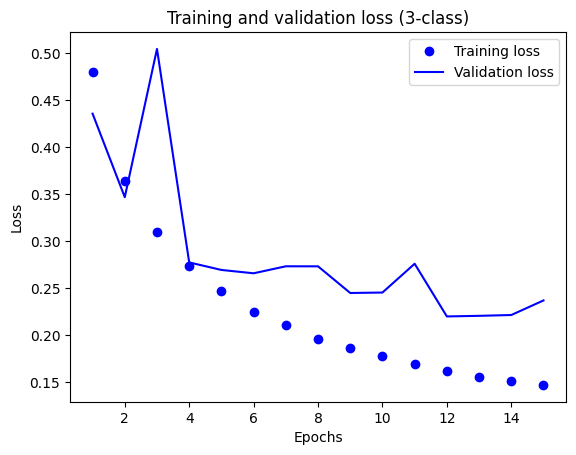

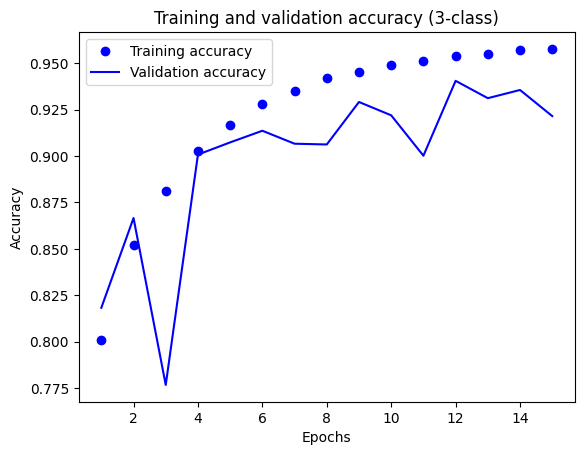

=== 3클래스 모델 Test Evaluation ===
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9437 - loss: 0.2053
381/381 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
  혼동 행렬 (3클래스)
[[1478   92   26]
 [  32 6266   72]
 [  47  395 3758]]

           분류 리포트 (3클래스)
                  precision    recall  f1-score   support

 No Diabetes (0)       0.95      0.93      0.94      1596
Pre-Diabetes (1)       0.93      0.98      0.95      6370
    Diabetes (2)       0.97      0.89      0.93      4200

        accuracy                           0.95     12166
       macro avg       0.95      0.93      0.94     12166
    weighted avg       0.95      0.95      0.95     12166



In [ ]:
# epochs별 훈련 및 검증 손실 시각화
loss = history_3cls.history["loss"]
val_loss = history_3cls.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss (3-class)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# epochs별 훈련 및 검증 정확도 시각화
plt.clf()
acc = history_3cls.history["accuracy"]
val_acc = history_3cls.history["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy (3-class)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 테스트 평가
print("=== 3클래스 모델 Test Evaluation ===")
model_3cls.evaluate(x_test_dict, test_labels)

# 예측 및 리포트
y_pred_prob = model_3cls.predict(x_test_dict)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_labels

print("  혼동 행렬 (3클래스)")
print(confusion_matrix(y_true, y_pred, labels=[0, 1, 2]))

print("\n           분류 리포트 (3클래스)")
print(classification_report(
    y_true,
    y_pred,
    target_names=['No Diabetes (0)', 'Pre-Diabetes (1)', 'Diabetes (2)']
))

